# 🧮 Handwritten Equation Solver — CNN Trainer

Trains a **14-class CNN** on:
- **Digits 0–9** → MNIST (60 000 images, 28×28)
- **Operators +, −, ×, ÷** → [Kaggle Handwritten Math Symbols](https://www.kaggle.com/datasets/sagyamthapa/handwritten-math-symbols)

All outputs are written to the `outputs/` sub-folder.

### Dataset layout
```
dataset/
    add/   *.png
    sub/   *.png
    mul/   *.png
    div/   *.png
```
Run all cells → `outputs/best_model.keras` is produced → launch `streamlit run draw.py`

## 0 · Install dependencies

## 1 · Imports

In [1]:
import os
import random
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import albumentations as A
from collections import Counter
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D,
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print(f"TensorFlow {tf.__version__}")
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow 2.21.0
GPU: []


## 2 · Configuration

In [2]:
DATASET_PATH = "./dataset"   # folder containing add/ sub/ mul/ div/
OUTPUT_DIR   = "./outputs"   # all artefacts written here

IMG_SIZE    = 28
NUM_CLASSES = 14   # 10 digits + 4 operators

# None = auto: min(median_count, max_op_count × 2)
TARGET_PER_CLASS = None
AUGMENT_HEAVY    = True

BATCH_SIZE = 128
EPOCHS     = 20
SEED       = 42

# Only 4 arithmetic operators — dec, eq, x, y, z intentionally excluded
OPERATOR_MAP = {"add": 10, "sub": 11, "mul": 12, "div": 13}

CLASS_NAMES         = list("0123456789") + ["+", "-", "×", "÷"]
CLASS_NAMES_FOLDERS = list("0123456789") + ["add", "sub", "mul", "div"]

random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

ELASTIC = A.ElasticTransform(alpha=8, sigma=4, p=0.7)

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Outputs → {os.path.abspath(OUTPUT_DIR)}")

Outputs → /Users/abhirupsain/Documents/TU_DRESDEN/STIPT/Courses/AI/AI_Project/outputs


## 3 · Plot helpers

In [3]:
def plot_training_curves(history_dict, out_path):
    epochs  = range(1, len(history_dict["loss"]) + 1)
    best_ep = history_dict["best_epoch"]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    for ax, metric in [(ax1, "accuracy"), (ax2, "loss")]:
        ax.plot(epochs, history_dict[metric],          label="Train",      linewidth=2)
        ax.plot(epochs, history_dict[f"val_{metric}"], label="Validation", linewidth=2, linestyle="--")
        ax.axvline(best_ep, color="gray", linestyle=":", label=f"Best epoch ({best_ep})")
        ax.set_title(metric.capitalize()); ax.set_xlabel("Epoch"); ax.grid(True, alpha=0.3); ax.legend()
    plt.tight_layout(); plt.savefig(out_path, dpi=150); plt.show()
    print(f"Saved {out_path}")


def plot_class_distribution(y_before, y_after, class_names, out_path, title="Class Distribution"):
    counts_b = [int((y_before == c).sum()) for c in range(len(class_names))]
    counts_a = [int((y_after  == c).sum()) for c in range(len(class_names))]
    x, w = np.arange(len(class_names)), 0.4
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.bar(x - w/2, counts_b, w, label="Before balancing", color="#4a90d9", alpha=0.8)
    ax.bar(x + w/2, counts_a, w, label="After balancing",  color="#2ecc71", alpha=0.8)
    ax.set_xticks(x); ax.set_xticklabels(class_names)
    ax.set_ylabel("Samples"); ax.set_title(title); ax.legend(); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout(); plt.savefig(out_path, dpi=150); plt.show()
    print(f"Saved {out_path}")
    print(f"Imbalance ratio  before : {max(counts_b)/min(counts_b):.1f}×")
    print(f"Imbalance ratio  after  : {max(counts_a)/min(counts_a):.1f}×")


def plot_confusion_matrix_advanced(y_true, y_pred, class_names, out_path):
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    ConfusionMatrixDisplay(cm,      display_labels=class_names).plot(ax=axes[0], cmap="Blues", colorbar=False)
    ConfusionMatrixDisplay(cm_norm, display_labels=class_names).plot(ax=axes[1], cmap="Blues", colorbar=False, values_format=".2f")
    axes[0].set_title("Confusion Matrix (Counts)")
    axes[1].set_title("Confusion Matrix (Normalized)")
    plt.tight_layout(); plt.savefig(out_path, dpi=150); plt.show()
    print(f"Saved {out_path}")

## 4 · Data loading

In [4]:
def load_mnist():
    (X_tr, y_tr), (X_te, y_te) = mnist.load_data()
    print(f"MNIST  train: {X_tr.shape}  test: {X_te.shape}")
    return (X_tr, y_tr), (X_te, y_te)


def load_operator_images(dataset_path, op_map, img_size=28):
    """
    Load operator images from dataset sub-folders.
    Conditional inversion: only inverts bright-background images (mean > 127)
    to produce dark-ink-on-black, matching MNIST convention.
    Folders not in op_map (dec, eq, x, y, z) are never loaded.
    """
    X, y = [], []
    for folder_name, label in op_map.items():
        folder = os.path.join(dataset_path, folder_name)
        if not os.path.exists(folder):
            raise FileNotFoundError(
                f"Missing folder: {folder}\nExpected: " + ", ".join(op_map.keys())
            )
        files = [f for f in os.listdir(folder) if f.lower().endswith((".png", ".jpg", ".jpeg"))]
        print(f"  {folder_name:>4}  (label {label}) : {len(files):5d} images")
        for fname in files:
            img = cv2.imread(os.path.join(folder, fname), cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            if img.mean() > 127:      # conditional inversion
                img = 255 - img
            img = cv2.resize(img, (img_size, img_size), interpolation=cv2.INTER_AREA)
            X.append(img); y.append(label)
    return np.array(X), np.array(y)

In [5]:
print("=== Loading data ===")
(X_mnist_tr, y_mnist_tr), (X_mnist_te, y_mnist_te) = load_mnist()

print("\nLoading operator images (add, sub, mul, div only) …")
X_ops, y_ops = load_operator_images(DATASET_PATH, OPERATOR_MAP, IMG_SIZE)
print(f"Total operator images: {len(X_ops)}")

X_ops_tr, X_ops_te, y_ops_tr, y_ops_te = train_test_split(
    X_ops, y_ops, test_size=0.2, stratify=y_ops, random_state=SEED
)

X_raw  = np.concatenate([X_mnist_tr, X_ops_tr])
y_raw  = np.concatenate([y_mnist_tr, y_ops_tr])
X_test = np.concatenate([X_mnist_te, X_ops_te])
y_test = np.concatenate([y_mnist_te, y_ops_te])

print(f"\nRaw combined train : {X_raw.shape}")
print("Raw class counts   :", {CLASS_NAMES[c]: int((y_raw==c).sum()) for c in range(NUM_CLASSES)})

=== Loading data ===
MNIST  train: (60000, 28, 28)  test: (10000, 28, 28)

Loading operator images (add, sub, mul, div only) …
   add  (label 10) :   596 images
   sub  (label 11) :   655 images
   mul  (label 12) :   577 images
   div  (label 13) :   618 images
Total operator images: 2446

Raw combined train : (61956, 28, 28)
Raw class counts   : {'0': 5923, '1': 6742, '2': 5958, '3': 6131, '4': 5842, '5': 5421, '6': 5918, '7': 6265, '8': 5851, '9': 5949, '+': 477, '-': 524, '×': 461, '÷': 494}


## 5 · Augmentation helpers

In [6]:
def _augment_one(img, strong=False):
    h, w = img.shape
    angle = random.uniform(-15, 15)
    img = cv2.warpAffine(img, cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0), (w, h), borderValue=0)
    tx, ty = random.uniform(-2, 2), random.uniform(-2, 2)
    img = cv2.warpAffine(img, np.float32([[1,0,tx],[0,1,ty]]), (w, h), borderValue=0)
    if strong:
        scale = random.uniform(0.85, 1.15)
        nw, nh = int(w*scale), int(h*scale)
        resized = cv2.resize(img, (nw, nh))
        canvas = np.zeros((h, w), dtype=np.uint8)
        y0, x0 = max(0,(h-nh)//2), max(0,(w-nw)//2)
        canvas[y0:y0+min(nh,h), x0:x0+min(nw,w)] = resized[:min(nh,h), :min(nw,w)]
        shear = random.uniform(-0.15, 0.15)
        img = cv2.warpAffine(canvas, np.float32([[1,shear,-shear*h/2],[0,1,0]]), (w,h), borderValue=0)
        img = ELASTIC(image=img)["image"]
        noise = np.random.normal(0, 8, img.shape).astype(np.int16)
        img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)
        if random.random() < 0.4:
            img = cv2.GaussianBlur(img, (3,3), 0)
    return img


def oversample_to_target(X, y, target, strong_aug=False):
    X_out, y_out = list(X), list(y)
    counts = Counter(y.tolist())
    for cls in sorted(counts):
        need = target - counts[cls]
        if need <= 0: continue
        src_idx = np.where(y == cls)[0]
        for _ in range(need):
            X_out.append(_augment_one(X[random.choice(src_idx)], strong=strong_aug))
            y_out.append(cls)
    X_out, y_out = np.array(X_out), np.array(y_out)
    perm = np.random.permutation(len(y_out))
    return X_out[perm], y_out[perm]

## 6 · Balance classes

In [7]:
counts     = Counter(y_raw.tolist())
count_vals = list(counts.values())

if TARGET_PER_CLASS is None:
    max_op_count = max(int((y_raw==c).sum()) for c in OPERATOR_MAP.values())
    target = min(int(np.median(count_vals)), max_op_count * 2)
    print(f"Auto target per class : {target}  (median={int(np.median(count_vals))}, max_op={max_op_count})")
else:
    target = TARGET_PER_CLASS
    print(f"Manual target per class : {target}")

print("\nOversampling … (may take a minute)")

mask_d = y_raw < 10
X_d, y_d = oversample_to_target(X_raw[mask_d], y_raw[mask_d], target, strong_aug=False)

mask_o = y_raw >= 10
X_o, y_o = oversample_to_target(X_raw[mask_o], y_raw[mask_o], target, strong_aug=AUGMENT_HEAVY)

X_balanced = np.concatenate([X_d, X_o])
y_balanced = np.concatenate([y_d, y_o])
perm = np.random.permutation(len(y_balanced))
X_balanced, y_balanced = X_balanced[perm], y_balanced[perm]

print(f"\nBalanced train set : {X_balanced.shape}")
for c, name in enumerate(CLASS_NAMES):
    print(f"  {name:>2}: {int((y_balanced==c).sum()):>6}")

Auto target per class : 1048  (median=5884, max_op=524)

Oversampling … (may take a minute)

Balanced train set : (64192, 28, 28)
   0:   5923
   1:   6742
   2:   5958
   3:   6131
   4:   5842
   5:   5421
   6:   5918
   7:   6265
   8:   5851
   9:   5949
   +:   1048
   -:   1048
   ×:   1048
   ÷:   1048


## 7 · Class distribution - before vs after

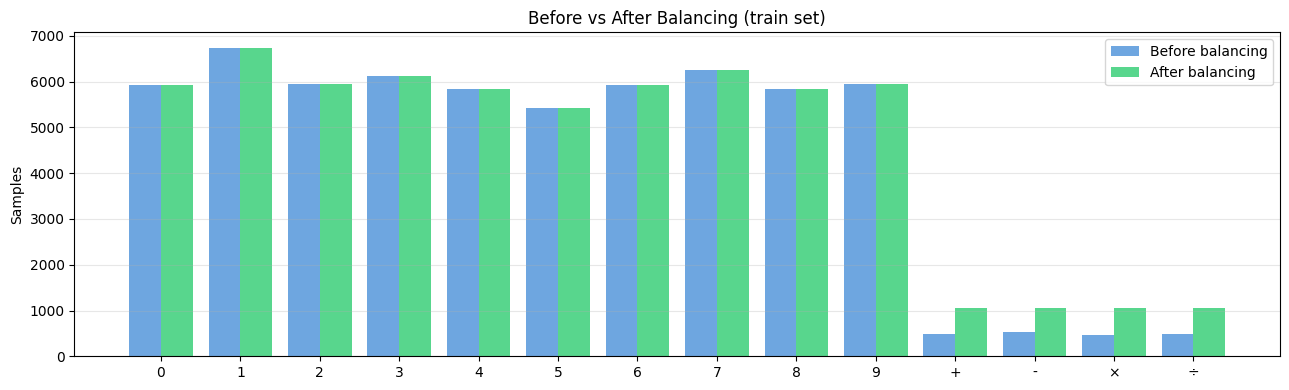

Saved ./outputs/class_distribution.png
Imbalance ratio  before : 14.6×
Imbalance ratio  after  : 6.4×


In [8]:
plot_class_distribution(
    y_raw, y_balanced, CLASS_NAMES,
    out_path=os.path.join(OUTPUT_DIR, "class_distribution.png"),
    title="Before vs After Balancing (train set)",
)

## 8 · Preprocess

In [9]:
X_tr = X_balanced.reshape(-1, 28, 28, 1) / 255.0
Y_tr = to_categorical(y_balanced, NUM_CLASSES)
X_te = X_test.reshape(-1, 28, 28, 1) / 255.0
Y_te = to_categorical(y_test, NUM_CLASSES)
print(f"X_tr: {X_tr.shape}  Y_tr: {Y_tr.shape}")
print(f"X_te: {X_te.shape}  Y_te: {Y_te.shape}")

X_tr: (64192, 28, 28, 1)  Y_tr: (64192, 14)
X_te: (10490, 28, 28, 1)  Y_te: (10490, 14)


## 9 · Build model

In [10]:
def build_model(num_classes=14):
    model = Sequential([
        Conv2D(32, 3, padding="same", activation="relu", input_shape=(28,28,1)),
        BatchNormalization(),
        Conv2D(32, 3, padding="same", activation="relu"),
        BatchNormalization(), MaxPooling2D(2), Dropout(0.25),
        Conv2D(64, 3, padding="same", activation="relu"),
        BatchNormalization(),
        Conv2D(64, 3, padding="same", activation="relu"),
        BatchNormalization(), MaxPooling2D(2), Dropout(0.25),
        Conv2D(128, 3, padding="same", activation="relu"),
        BatchNormalization(), Dropout(0.25),
        GlobalAveragePooling2D(),
        Dense(256, activation="relu"),
        BatchNormalization(), Dropout(0.5),
        Dense(num_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
        loss="categorical_crossentropy", metrics=["accuracy"],
    )
    return model

model = build_model(NUM_CLASSES)
model.summary()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         3,598 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 177,774 (694.43 KB)

 Trainable params: 176,622 (689.93 KB)

 Non-trainable params: 1,152 (4.50 KB)

## 10 · Train

In [11]:
callbacks = [
    EarlyStopping(monitor="val_accuracy", mode="max", patience=5,
                  min_delta=0.0005, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1),
]

augment_layer = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.08,          fill_mode="constant", fill_value=0.0),
    tf.keras.layers.RandomTranslation(0.08, 0.08, fill_mode="constant", fill_value=0.0),
    tf.keras.layers.RandomZoom(0.10,              fill_mode="constant", fill_value=0.0),
])

train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_tr, Y_tr))
    .shuffle(10_000, seed=SEED).batch(BATCH_SIZE)
    .map(lambda x, y: (augment_layer(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)
val_dataset = (
    tf.data.Dataset.from_tensor_slices((X_te, Y_te))
    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
)

hist = model.fit(
    train_dataset, epochs=EPOCHS, validation_data=val_dataset,
    callbacks=callbacks, verbose=1,
)

history_dict = dict(hist.history)
history_dict["best_epoch"]        = int(np.argmax(hist.history["val_accuracy"])) + 1
history_dict["best_val_accuracy"] = float(max(hist.history["val_accuracy"]))

with open(os.path.join(OUTPUT_DIR, "training_history.json"), "w", encoding="utf-8") as f:
    json.dump(history_dict, f, indent=2)
print("Saved training_history.json")

Epoch 1/20
502/502 ━━━━━━━━━━━━━━━━━━━━ 51s 97ms/step - accuracy: 0.8357 - loss: 0.5398 - val_accuracy: 0.8570 - val_loss: 0.5105 - learning_rate: 0.0010
Epoch 2/20
502/502 ━━━━━━━━━━━━━━━━━━━━ 51s 101ms/step - accuracy: 0.9476 - loss: 0.1642 - val_accuracy: 0.9842 - val_loss: 0.0553 - learning_rate: 0.0010
Epoch 3/20
502/502 ━━━━━━━━━━━━━━━━━━━━ 50s 99ms/step - accuracy: 0.9610 - loss: 0.1226 - val_accuracy: 0.9861 - val_loss: 0.0484 - learning_rate: 0.0010
Epoch 4/20
502/502 ━━━━━━━━━━━━━━━━━━━━ 50s 99ms/step - accuracy: 0.9673 - loss: 0.1003 - val_accuracy: 0.9914 - val_loss: 0.0268 - learning_rate: 0.0010
Epoch 5/20
502/502 ━━━━━━━━━━━━━━━━━━━━ 52s 104ms/step - accuracy: 0.9716 - loss: 0.0886 - val_accuracy: 0.9900 - val_loss: 0.0309 - learning_rate: 0.0010
Epoch 6/20
502/502 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9737 - loss: 0.0807
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
502/502 ━━━━━━━━━━━━━━━━━━━━ 55s 109ms/step - accuracy: 0.9741 -

## 11 · Training curves

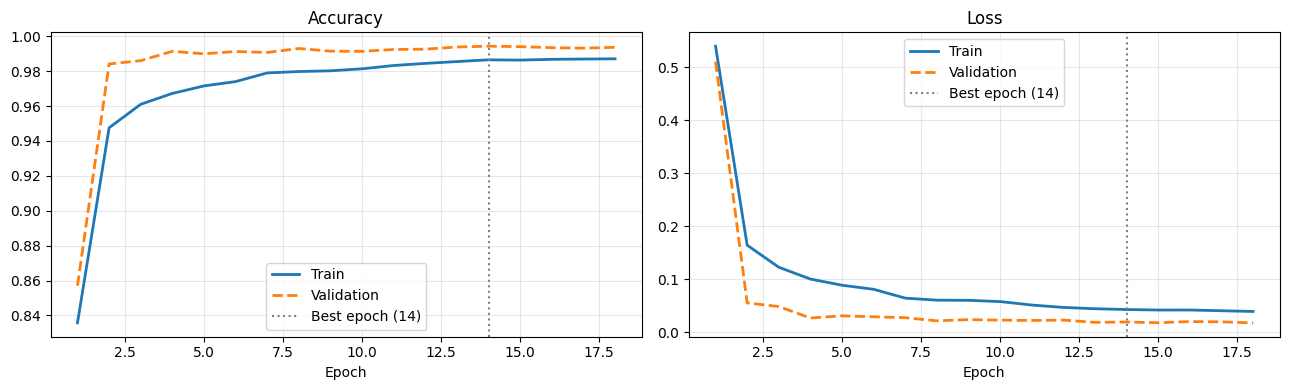

Saved ./outputs/training_curves.png


In [12]:
plot_training_curves(history_dict, out_path=os.path.join(OUTPUT_DIR, "training_curves.png"))

## 12 · Evaluate

In [13]:
loss, acc = model.evaluate(X_te, Y_te, verbose=0)
preds = np.argmax(model.predict(X_te, verbose=0), axis=1)

digit_mask = y_test < 10
op_mask    = y_test >= 10
digit_acc  = (preds[digit_mask] == y_test[digit_mask]).mean() * 100
op_acc     = (preds[op_mask]    == y_test[op_mask]).mean()    * 100

print(f"Test accuracy     : {acc*100:.2f}%   loss : {loss:.4f}")
print(f"Digit accuracy    : {digit_acc:.2f}%")
print(f"Operator accuracy : {op_acc:.2f}%")

print("\nPer-class accuracy:")
for c in range(NUM_CLASSES):
    mask = y_test == c
    if mask.any():
        print(f"  {CLASS_NAMES[c]:>2} : {(preds[mask]==c).mean()*100:6.2f}%  ({mask.sum()} samples)")

print("\nClassification report:")
print(classification_report(y_test, preds, target_names=CLASS_NAMES, zero_division=0))

Test accuracy     : 99.39%   loss : 0.0186
Digit accuracy    : 99.38%
Operator accuracy : 99.59%

Per-class accuracy:
   0 :  99.69%  (980 samples)
   1 :  99.30%  (1135 samples)
   2 :  99.13%  (1032 samples)
   3 :  99.90%  (1010 samples)
   4 :  99.80%  (982 samples)
   5 :  99.10%  (892 samples)
   6 :  98.85%  (958 samples)
   7 :  99.61%  (1028 samples)
   8 :  99.69%  (974 samples)
   9 :  98.71%  (1009 samples)
   + :  99.16%  (119 samples)
   - : 100.00%  (131 samples)
   × :  99.14%  (116 samples)
   ÷ : 100.00%  (124 samples)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      0.99      0.99      1135
           2       1.00      0.99      0.99      1032
           3       0.99      1.00      1.00      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958


## 13 · Confusion matrices

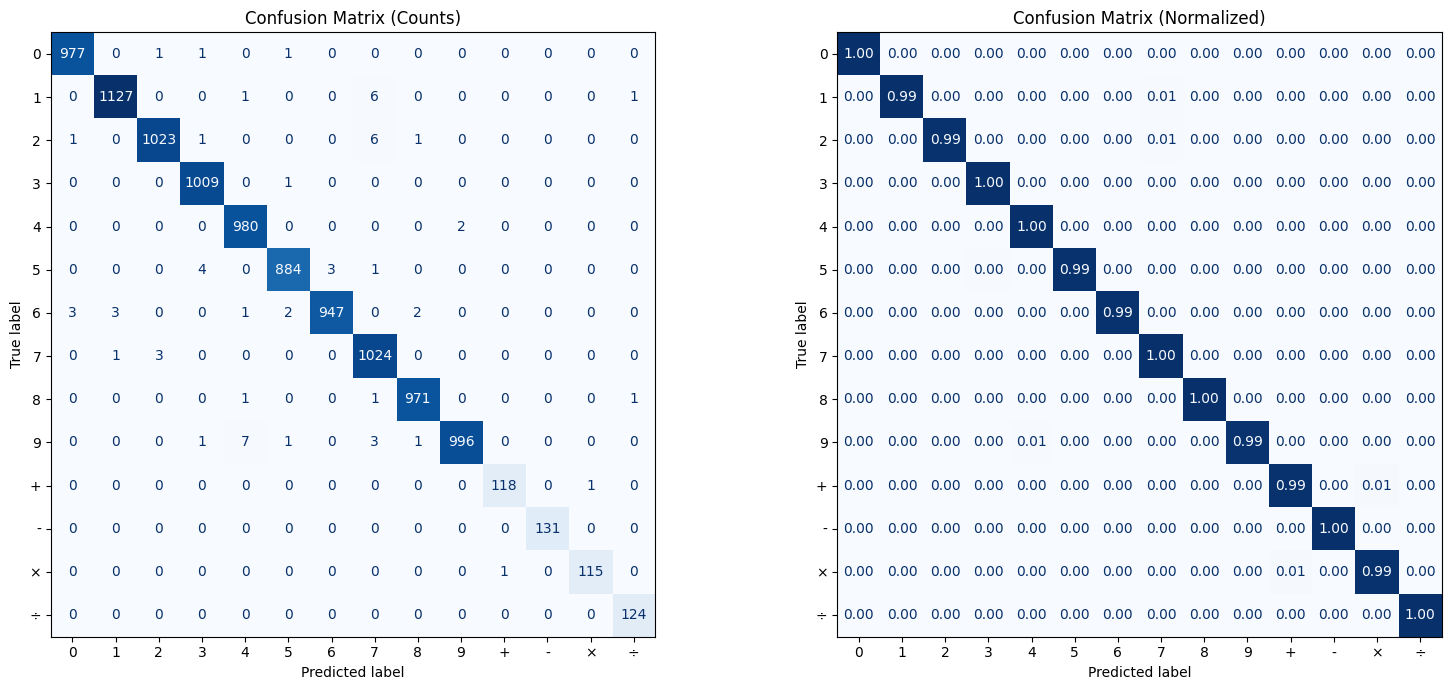

Saved ./outputs/confusion_matrix.png


In [14]:
plot_confusion_matrix_advanced(
    y_test, preds, CLASS_NAMES,
    out_path=os.path.join(OUTPUT_DIR, "confusion_matrix.png"),
)

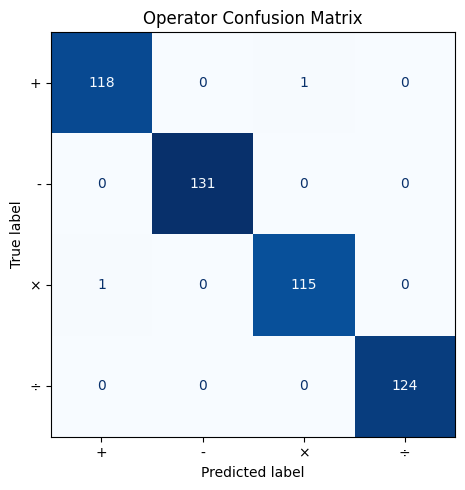

Saved ./outputs/operator_confusion_matrix.png


In [15]:
# Operator-only confusion matrix
op_idx = y_test >= 10
op_cm  = confusion_matrix(y_test[op_idx] - 10, preds[op_idx] - 10)
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(op_cm, display_labels=["+", "-", "×", "÷"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Operator Confusion Matrix")
plt.tight_layout()
op_cm_path = os.path.join(OUTPUT_DIR, "operator_confusion_matrix.png")
plt.savefig(op_cm_path, dpi=150); plt.show()
print(f"Saved {op_cm_path}")

## 14 · Save model & metadata

In [16]:
for fname in ("best_model.keras", "model.keras"):
    p = os.path.join(OUTPUT_DIR, fname)
    model.save(p)
    print(f"Saved {p}")

# Round-trip check
rt_model = load_model(os.path.join(OUTPUT_DIR, "best_model.keras"))
_, rt_acc = rt_model.evaluate(X_te, Y_te, verbose=0)

# class_names.json — folder names (not display symbols)
with open(os.path.join(OUTPUT_DIR, "class_names.json"), "w", encoding="utf-8") as f:
    json.dump(CLASS_NAMES_FOLDERS, f, indent=2, ensure_ascii=False)
print(f"Saved class_names.json → {CLASS_NAMES_FOLDERS}")

# class_info.json
class_info = {
    "num_classes": NUM_CLASSES, "img_size": IMG_SIZE,
    "classes": [{"index": i, "folder": CLASS_NAMES_FOLDERS[i], "symbol": CLASS_NAMES[i],
                 "samples_balanced": int((y_balanced==i).sum())} for i in range(NUM_CLASSES)],
}
with open(os.path.join(OUTPUT_DIR, "class_info.json"), "w", encoding="utf-8") as f:
    json.dump(class_info, f, indent=2, ensure_ascii=False)
print("Saved class_info.json")

with open(os.path.join(OUTPUT_DIR, "training_history.json"), "w", encoding="utf-8") as f:
    json.dump(history_dict, f, indent=2)

print("Saved training_history.json")

# evaluation_results.json
with open(os.path.join(OUTPUT_DIR, "evaluation_results.json"), "w", encoding="utf-8") as f:
    json.dump({"test_accuracy": float(acc), "digit_accuracy": float(digit_acc),
               "operator_accuracy": float(op_acc)}, f, indent=2)
print("Saved evaluation_results.json")

# training_config.json
with open(os.path.join(OUTPUT_DIR, "training_config.json"), "w", encoding="utf-8") as f:
    json.dump({"IMG_SIZE": IMG_SIZE, "NUM_CLASSES": NUM_CLASSES, "BATCH_SIZE": BATCH_SIZE,
               "EPOCHS": EPOCHS, "TARGET_PER_CLASS": target, "AUGMENT_HEAVY": AUGMENT_HEAVY,
               "excluded_folders": ["dec", "eq", "x", "y", "z"]}, f, indent=2)
print("Saved training_config.json")

print("\n All outputs saved to", OUTPUT_DIR)
print("Run:  streamlit run draw.py")

Saved ./outputs/best_model.keras
Saved ./outputs/model.keras


ValueError: You must call `compile()` before using the model.